# MLP Matrix Learning Test

This project loads model parameters from MLP matrix learning training and test it on commit embeddings

## Initialization

Initializing MLP network and load embedding vectors

In [1]:
import torch
import torch.nn as nn
import numpy as np

class MLPEmbedding(nn.Module):
    def __init__(self, input_dim=768, output_dim=64):
        super().__init__()
        self.net = nn.Sequential(
                    nn.Linear(768, 128),
                    nn.Tanh(),
                    nn.Linear(128, 64)
                )
    def forward(self, x):
        return self.net(x)
    
model = MLPEmbedding(768, 64)

## Load model parameters

In [2]:
state_dict = torch.load("triplet_intraproject_2.pth", map_location=torch.device('cpu'))  # or 'cuda' if using GPU

model.load_state_dict(state_dict)
model.eval()

MLPEmbedding(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
  )
)

In [3]:
npy_path = 'data/initial_embedding/embeddings_accumulo.npy'
embeddings = np.load(npy_path)

embeddings.shape

(10741, 768)

convert embeddings to PyTorch tensor

In [4]:
embeddings_tensor = torch.from_numpy(embeddings).float()

## Feed Embeddings through MLP

In [5]:
with torch.no_grad():
    compressed_embeddings = model(embeddings_tensor)
compressed_embeddings.shape
## Clustering






torch.Size([10741, 64])

## Visualization using t-SNE

In [6]:
import pandas as pd

COMMIT_LABELS_PATH = 'data/commit_info/accumulo_labels.csv'
try:
    labels_df = pd.read_csv(COMMIT_LABELS_PATH)
    # Assuming your labels are in a column named 'label'
    # If not, replace 'label' with the actual column name.
    labels = labels_df['predict']
except FileNotFoundError:
    print(f"Error: '{COMMIT_LABELS_PATH}' not found. Please ensure the CSV file is in the correct directory.")
    # You might want to exit or handle this error differently
except KeyError:
    print(f"Error: 'predict' column not found in '{COMMIT_LABELS_PATH}'. Please check the column name.")

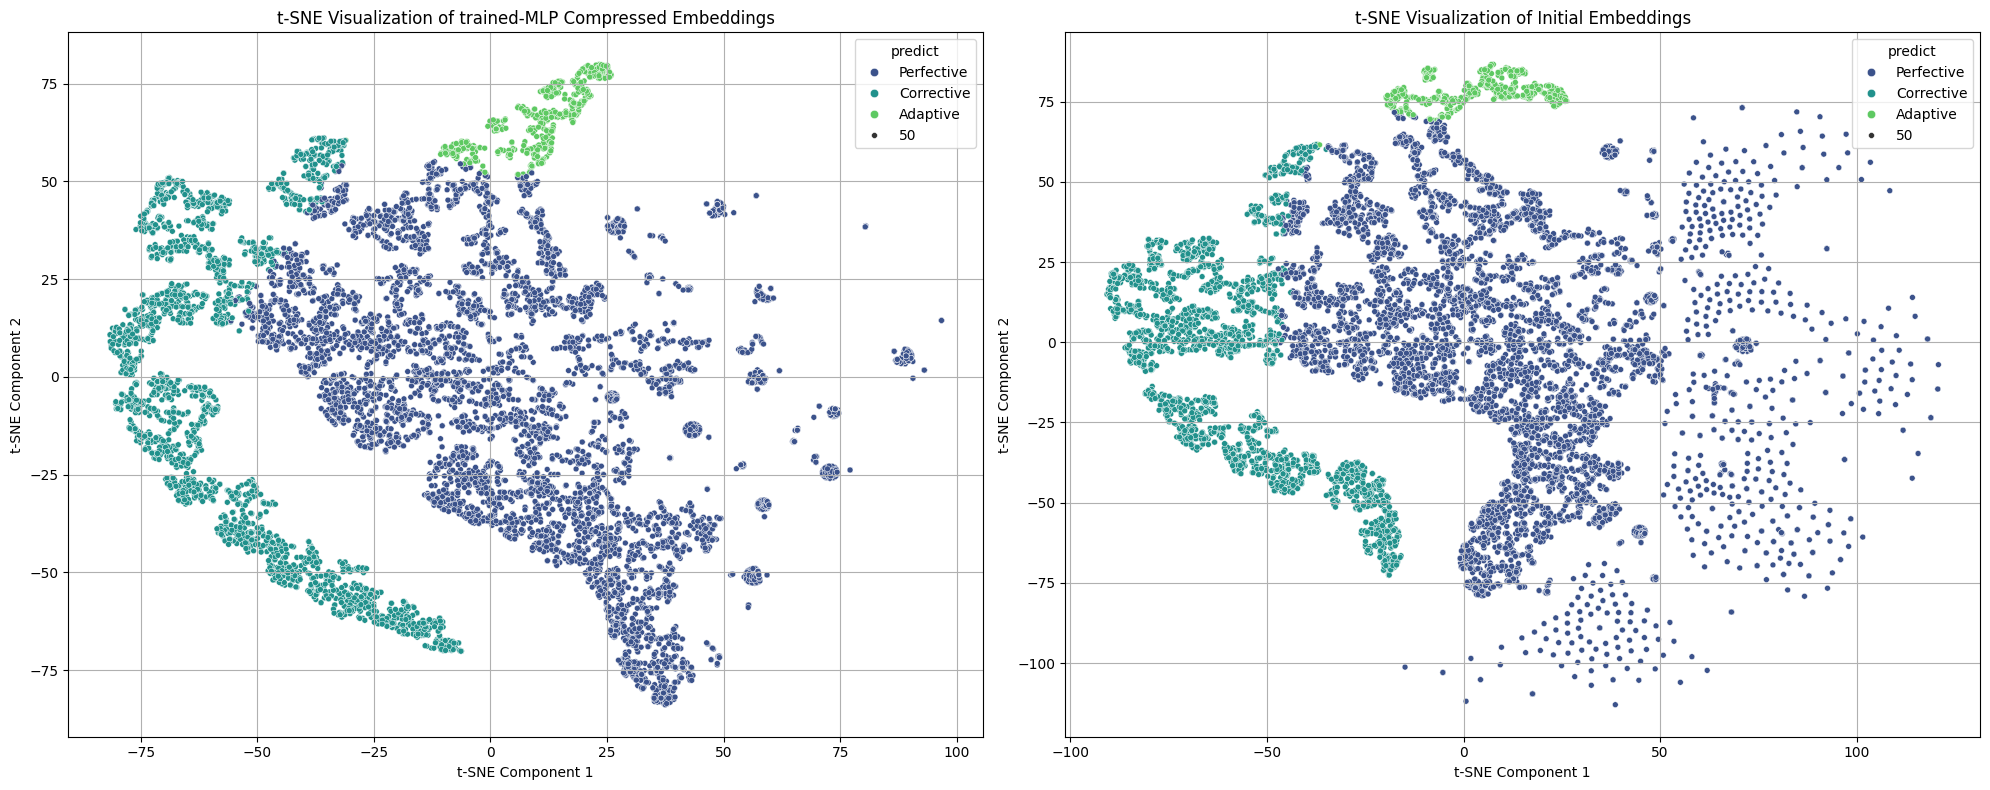

In [7]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Reduce the dimensions of the compressed embeddings to 2D
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(compressed_embeddings)

# Plot compressed embeddings
sns.scatterplot(x=embeddings_2d[:, 0], 
                y=embeddings_2d[:, 1], 
                palette='viridis',
                hue=labels,
                size=50,
                ax=ax1)
ax1.set_title('t-SNE Visualization of trained-MLP Compressed Embeddings')
ax1.set_xlabel('t-SNE Component 1')
ax1.set_ylabel('t-SNE Component 2')
ax1.grid(True)

# Plot initial embeddings
initial_tsne = TSNE(n_components=2, random_state=42)
initial_embeddings_2d = initial_tsne.fit_transform(embeddings_tensor)

sns.scatterplot(x=initial_embeddings_2d[:, 0], 
                y=initial_embeddings_2d[:, 1], 
                palette='viridis',
                hue=labels,
                size=50,
                ax=ax2)
ax2.set_title('t-SNE Visualization of Initial Embeddings')
ax2.set_xlabel('t-SNE Component 1')
ax2.set_ylabel('t-SNE Component 2')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [8]:
# Save compressed embeddings
compressed_embeddings_np = compressed_embeddings.numpy()
np.save('embedding/embeddings_accumulo_after_compressed_consider_files.npy', compressed_embeddings_np)



## Visualization using UMAP


In [9]:
import umap
reducer = umap.UMAP()
reduced_compressed_embeddings = reducer.fit_transform(compressed_embeddings_np)
reduced_initial_embeddings = reducer.fit_transform(embeddings_tensor)

/Users/savirarama/Documents/Embedding-Clustering-Visualization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/savirarama/Documents/Embedding-Clustering-Visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/savirarama/Documents/Embedding-Clustering-Visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


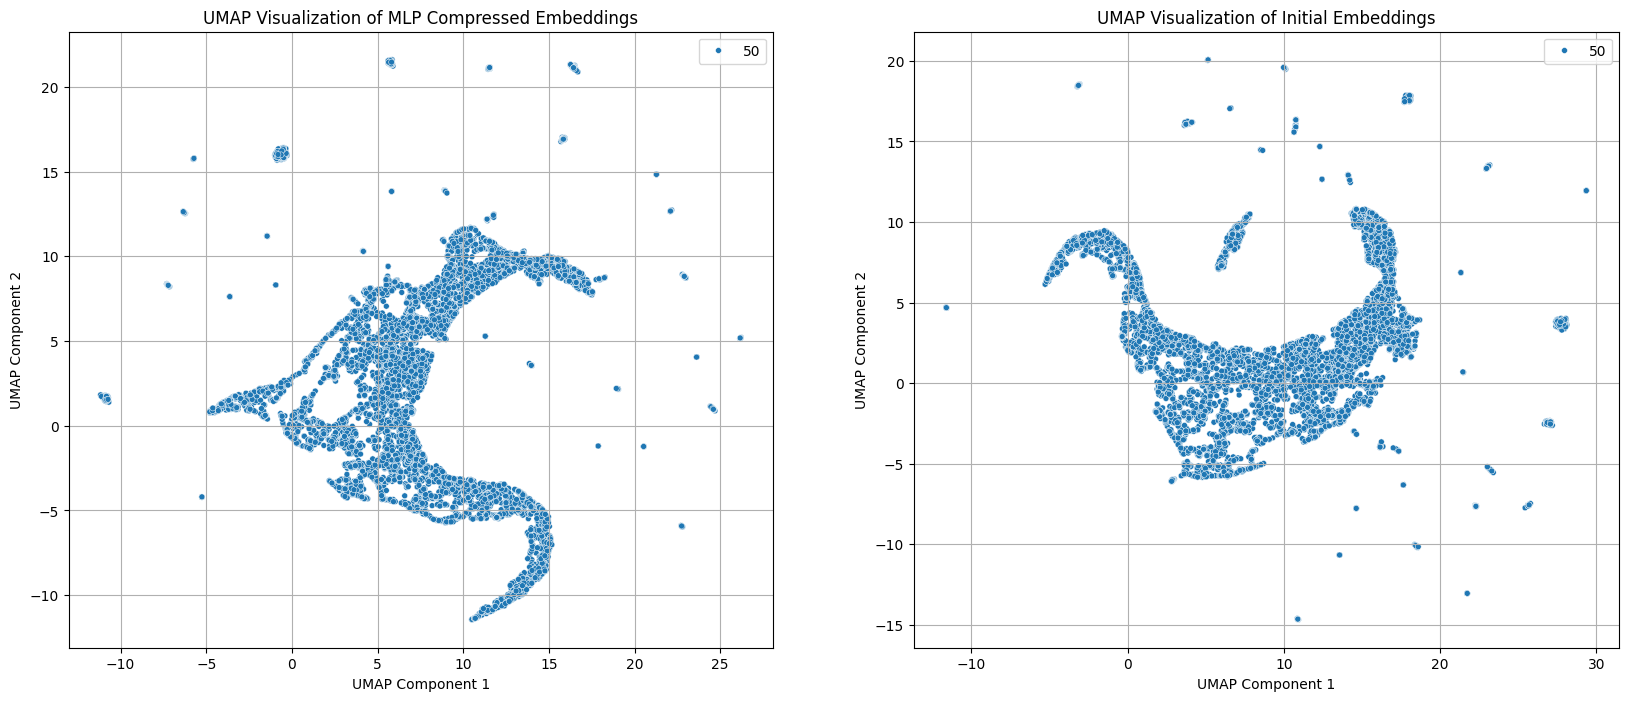

In [10]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot compressed embeddings
sns.scatterplot(x=reduced_compressed_embeddings[:, 0], 
                y=reduced_compressed_embeddings[:, 1], 
                size=50,
                ax=ax1)
ax1.set_title('UMAP Visualization of MLP Compressed Embeddings')
ax1.set_xlabel('UMAP Component 1')
ax1.set_ylabel('UMAP Component 2')
ax1.grid(True)

# Plot compressed embeddings
sns.scatterplot(x=reduced_initial_embeddings[:, 0], 
                y=reduced_initial_embeddings[:, 1], 
                size=50,
                ax=ax2)
ax2.set_title('UMAP Visualization of Initial Embeddings')
ax2.set_xlabel('UMAP Component 1')
ax2.set_ylabel('UMAP Component 2')
ax2.grid(True)